In [1]:
# !pip install git+https://github.com/sichinaga/PyDMD@sparse-mode-bopdmd-FINAL
import numpy as np
import matplotlib.pyplot as plt
from pydmd import SparseBOPDMD
from pydmd.sbopdmd_utils import *

# SET ALL DATA PARAMETERS:
f1 = 0.5  # frequency of mode 1
f2 = 1.0  # frequency of mode 2
f3 = 1.5  # frequency of mode 3
nx = 50  # number of pixels along the horizontal
ny = nx  # number of pixels along the vertical
nt = 1000  # number of data snapshots
dt = 0.01  # time-step size
sigma = 0.8  # noise magnitude

# Define the true DMD eigenvalues.
true_eigs = 1j * 2 * np.pi * np.array([f1, f2, f3])

# Define the spatial and temporal grid.
n = nx * ny
x = np.arange(nx)
y = np.arange(ny)
t = np.arange(nt) * dt
Xgrid, Ygrid = np.meshgrid(x, y)

# Define mode 1 (gradient mode).
u1 = np.tile(np.linspace(-1, 1, nx), (ny, 1)).T
t1 = np.exp(true_eigs[0] * t)
X1 = np.outer(u1.flatten(), t1)

# Define mode 2 (Gaussian mode).
u2 = np.exp(-(0.5 / nx) * ((Xgrid - 0.5 * nx) ** 2 + (Ygrid - 0.5 * ny) ** 2))
t2 = np.exp(true_eigs[1] * t)
X2 = np.outer(u2.flatten(), t2)

# Define mode 3 (square mode).
square_start = int(0.2 * nx)
square_end = int(0.5 * nx)
u3 = np.zeros((nx, ny))
u3[square_start:square_end, square_start:square_end] = 1.0
t3 = np.exp(true_eigs[2] * t)
X3 = np.outer(u3.flatten(), t3)

# Build data matrix.
X_clean = X1 + X2 + X3

# Add measurement noise.
rng1 = np.random.default_rng(seed=1234)
rng2 = np.random.default_rng(seed=5678)
real_noise = sigma * rng1.standard_normal((n, nt))
imag_noise = sigma * 1j * rng2.standard_normal((n, nt))
X = X_clean + real_noise + imag_noise

sp_optdmd = SparseBOPDMD(
    svd_rank=4,
    SR3_step=1,
    mode_regularizer="l1",
    regularizer_params={"lambda": 0.01},
    apply_debias=True,
).fit(X, t)

/opt/anaconda3/envs/sparse-mode-dmd/lib/python3.13/site-packages/pydmd/bopdmd.py:1045: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with the varpro_opts_dict and consider setting verbose=True.
  warnings.warn(msg)


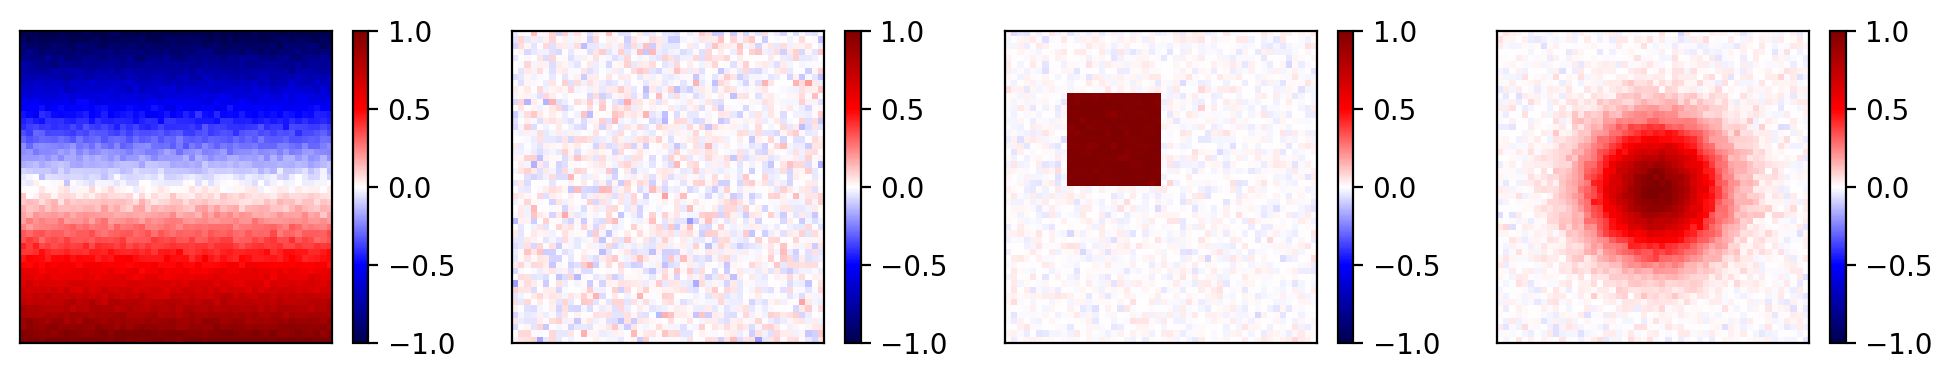

modes.shape = (4, 2500)


In [2]:
modes = (sp_optdmd.modes @ np.diag(sp_optdmd.amplitudes)).T

fig, axes = plt.subplots(1, 4, figsize=(10, 2), dpi=200)
for i, ax in enumerate(axes):
    im = ax.imshow(modes[i].reshape(ny, nx).real, vmin=-1, vmax=1, cmap="seismic")
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

print(f"modes.shape = {modes.shape}")

In [3]:
metric_names = ["Max norm", "Column-wise", "Row-wise"]
active_thresh = 0.1
global_thresh = 0.5

all_thresh = []
all_idx_global = []

for k, metric in enumerate(metric_names):
    print(metric)
    print("=================")
    if k == 0:
        # (1) Compute the maximum value across all modes (original).
        mode_max = np.max(np.abs(modes))
        elementwise_thresh = active_thresh * mode_max * np.ones(modes.shape)
    elif k == 1:
        # (2) Compute the maximum value for each mode (column-wise).
        mode_max = np.max(np.abs(modes), axis=1)
        elementwise_thresh = active_thresh * np.tile(mode_max, (modes.shape[1], 1)).T
    else:
        # (3) Compute the maximum value for each feature (row-wise).
        mode_max = np.max(np.abs(modes), axis=0)
        elementwise_thresh = active_thresh * np.tile(mode_max, (modes.shape[0], 1))

    print(f"Maximum value(s): {mode_max}")
    print(f"Pixels are considered active if value surpasses: {active_thresh * mode_max}")

    num_active = np.sum(np.abs(modes) > elementwise_thresh, axis=1)
    print(f"Number of active pixels (out of {n}): {num_active}")
    print(f"Mode is considered global if number of active pixels surpasses: {global_thresh * n}")

    idx_global = np.where(num_active > global_thresh * n)[0].tolist()
    print(f"Global mode indices found: {idx_global}")

    all_thresh.append(elementwise_thresh)
    all_idx_global.append(idx_global)
    print("=================")

Max norm
Maximum value(s): 1.070485428660209
Pixels are considered active if value surpasses: 0.1070485428660209
Number of active pixels (out of 2500): [2250  346  226  731]
Mode is considered global if number of active pixels surpasses: 1250.0
Global mode indices found: [0]
Column-wise
Maximum value(s): [1.05318211 0.20596969 1.07048543 1.02826741]
Pixels are considered active if value surpasses: [0.10531821 0.02059697 0.10704854 0.10282674]
Number of active pixels (out of 2500): [2254 2306  226  752]
Mode is considered global if number of active pixels surpasses: 1250.0
Global mode indices found: [0, 1]
Row-wise
Maximum value(s): [1.02287303 0.97432251 0.99231763 ... 0.98376687 1.03907801 1.00432076]
Pixels are considered active if value surpasses: [0.1022873  0.09743225 0.09923176 ... 0.09837669 0.1039078  0.10043208]
Number of active pixels (out of 2500): [2403 1283  671 1202]
Mode is considered global if number of active pixels surpasses: 1250.0
Global mode indices found: [0, 1]


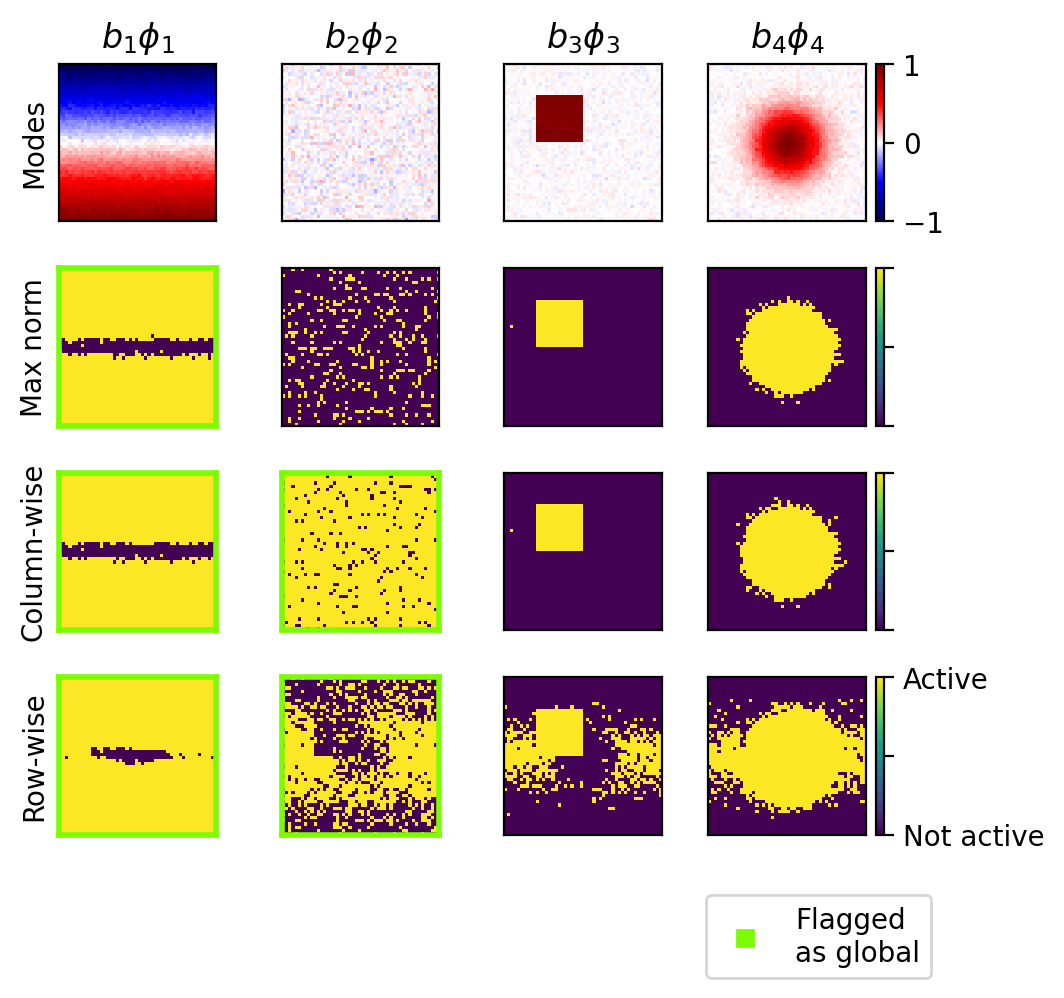

In [4]:
fig, axes = plt.subplots(4, 4, figsize=(5.5, 5), dpi=200)
for i, ax in enumerate(axes[0]):
    im = ax.imshow(modes[i].reshape(ny, nx).real, vmin=-1, vmax=1, cmap="seismic")
    ax.set_title(f"$b_{i + 1} \\phi_{i + 1}$")
    ax.set_xticks([])
    ax.set_yticks([])
    if i == 0:
        ax.set_ylabel("Modes")
    if i == 3:
        fig.colorbar(im, ax=ax)

for k, metric in enumerate(metric_names):
    elementwise_thresh = all_thresh[k]
    index_global = all_idx_global[k]

    for i, ax in enumerate(axes[k + 1]):
        im = ax.imshow((np.abs(modes) > elementwise_thresh)[i].reshape(ny, nx))
        ax.set_xticks([])
        ax.set_yticks([])
        if i in index_global:
            for spine in ax.spines.values():
                spine.set_color("lawngreen")
                spine.set_linewidth(2)

        if i == 0:
            ax.set_ylabel(metric)
        if i == 3:
            cbar = fig.colorbar(im, ax=ax, ticks=[0.0, 0.5, 1.0])
            if k == 2:
                cbar.ax.set_yticklabels(["Not active", "", "Active"])
            else:
                cbar.ax.set_yticklabels(["", "", ""])

axes[-1, -1].plot([], [], "s", c="lawngreen", lw=2, label="Flagged\nas global")
axes[-1, -1].legend(loc="lower left", bbox_to_anchor=[-0.1, -1.0])
plt.tight_layout()
plt.show()